In [1]:
# import packages and BTMS_model

import os
import re
import io
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import lib.BTMS_model as BTMS_model
import CoolProp.CoolProp as CP

plt.rcParams['axes.unicode_minus'] = False


In [2]:
# result-file naming configuration
# [RESULTID]_[SCN]_[BTMS]_[MODEL]_[TASK].[ext]
# This notebook runs one selected liquid-cooling validation condition using the 1D model.

CASE_ID = 'C0009'
REVISION = 'R00'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'LC'
MODEL_CODE = '1D'
TASK_CODE = 'VAL'

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
NOTEBOOK_NAME = f'{RESULT_BASENAME}.ipynb'
OUTPUT_DIR = os.path.join(os.getcwd(), 'data_results')
RESULT_FIGURE_NAME = 'C0009R00_PARK25_LC_1D_VAL.png'

print(f'Result basename: {RESULT_BASENAME}')
print(f'Notebook file: {NOTEBOOK_NAME}')
print(f'Temperature figure: {RESULT_FIGURE_NAME}')


Result basename: C0009R00_PARK25_LC_1D_VAL
Notebook file: C0009R00_PARK25_LC_1D_VAL.ipynb
Temperature figure: C0009R00_PARK25_LC_1D_VAL.png


In [3]:
# read the single-cell heat-generation profile Qbat(W)

# Keep the physical simulation duration unchanged, while using the original time step.
SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                 # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the original variable name for downstream compatibility.
# Here SIM_TIME_S means the number of numerical time steps, not the physical duration.
SIM_TIME_S = NUM_STEPS

file_name = os.path.join(
    os.getcwd(),
    'data',
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx'
)

if not os.path.isfile(file_name):
    raise FileNotFoundError(
        f'Heat-generation data file not found: {file_name}\n'
        'Place the Excel file in the data folder beside this notebook.'
    )

df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)

# The source Qbat data are treated as 1-s samples. For dt = 1.0 s,
# each 1-s heat-generation value is used for one numerical time step.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')

Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [4]:
# model settings and selected single operating condition

# battery cell properties
# Initial battery temperature is set equal to the inlet-water temperature.
BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg
    'cp_bat': 830.0,         # J/(kg K)
    'D_bat': 18e-3,          # m
    'H_bat': 65e-3,          # m
}

# 1D module layout
MODULE_LAYOUT = {
    'N_r': 20,               # cells/control volumes along the coolant-flow direction
    'N_c': 16,               # battery columns in the transverse direction
}

# coolant / water settings
LIQUID_SETTINGS = {
    'fluid': 'Water',
    'p_water': 101325.0,      # Pa
    'L_channel': 0.41423277,  # m, fixed channel length
    'plate_thickness': 0.012, # m, equivalent conduction thickness used in R_plate
    'k_plate': 202.4,         # W/(m K), aluminium thermal conductivity

    # Fixed Park-module and aluminium-plate geometry used for mass calculation
    'S_T': 1.25 * BATTERY_PROPS['D_bat'], # m, transverse cell pitch
    'plate_extra_height': 4e-3,            # m, plate height = Dh + 4 mm
    'rho_plate': 2719.0,                   # kg/m3, aluminium density

    # Pump and additional-component settings
    'pump_efficiency': 0.35,
    'K_minor': 0.0,
    'm_pump': 0.0,                         # kg; update when pump mass is specified
    'm_pipe': 0.0,                         # kg; update when pipe mass is specified
}

# liquid-cooling operating period
# Water cooling is active during the full mission.
COOLING_PERIOD = {
    't_cruise_start': 180.0,
    't_cruise_end': 1560.0,
}

# solver settings passed to BTMS_model.solve_coolant_temperature_distribution
SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}

# mission-stage definitions for result indicators
mission_stages = [
    ('takeoff',       0.0,    6.0),
    ('climb',         6.0,   36.0),
    ('transition1',  36.0,  180.0),
    ('cruise',      180.0, 1560.0),
    ('transition2',1560.0, 1704.0),
    ('descent',    1704.0, 1734.0),
    ('hover',      1734.0, 1914.0),
    ('landing',    1914.0, 1920.0),
]

# Selected thermally favourable representative condition
# T_water = 20 degC
# total coolant mass flow rate = 0.060 kg/s
# hydraulic diameter = 4 mm
# number of parallel channels = 20
SELECTED_CONDITION = {
    'case_id': f'{CASE_ID}_S001',
    'T_water': 20.0,          # degC
    'm_dot_total': 0.060,     # kg/s, total system mass flow rate
    'num_parallel_channels': 20,
    'Dh': 4.0e-3,             # m
}

# Map configuration values to variables used by the downstream calculations.
m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']
A_battery = np.pi * D_bat * H_bat

N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_r

fluid = LIQUID_SETTINGS['fluid']
p_water = LIQUID_SETTINGS['p_water']
L_channel = LIQUID_SETTINGS['L_channel']
plate_thickness = LIQUID_SETTINGS['plate_thickness']
k_plate = LIQUID_SETTINGS['k_plate']
S_T = LIQUID_SETTINGS['S_T']
plate_extra_height = LIQUID_SETTINGS['plate_extra_height']
rho_plate = LIQUID_SETTINGS['rho_plate']
pump_efficiency = LIQUID_SETTINGS['pump_efficiency']
K_minor = LIQUID_SETTINGS['K_minor']
m_pump = LIQUID_SETTINGS['m_pump']
m_pipe = LIQUID_SETTINGS['m_pipe']

t_cruise_start = COOLING_PERIOD['t_cruise_start']
t_cruise_end = COOLING_PERIOD['t_cruise_end']

# Liquid cooling is active during the full mission.
pump_operation_time = SIM_DURATION_S

solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']

# The solver uses the equivalent number of transverse cells represented by one channel.
SELECTED_CONDITION['num_cell_seg'] = (
    N_c / SELECTED_CONDITION['num_parallel_channels']
)

print('Selected single condition:')
print(f"  T_water = {SELECTED_CONDITION['T_water']:.1f} degC")
print(f"  m_dot_total = {SELECTED_CONDITION['m_dot_total']:.3f} kg/s")
print(f"  Dh = {SELECTED_CONDITION['Dh'] * 1e3:.1f} mm")
print(f"  N_ch = {SELECTED_CONDITION['num_parallel_channels']}")
print(f"  num_cell_seg = {SELECTED_CONDITION['num_cell_seg']:.3f}")


Selected single condition:
  T_water = 20.0 degC
  m_dot_total = 0.060 kg/s
  Dh = 4.0 mm
  N_ch = 20
  num_cell_seg = 0.800


In [5]:
# build the selected single case

single_case = {
    'case_id': SELECTED_CONDITION['case_id'],
    'T_water': float(SELECTED_CONDITION['T_water']),
    'm_dot_total': float(SELECTED_CONDITION['m_dot_total']),
    'num_cell_seg': float(SELECTED_CONDITION['num_cell_seg']),
    'Dh': float(SELECTED_CONDITION['Dh']),
}

num_parallel_channels_check = int(round(N_c / single_case['num_cell_seg']))
if num_parallel_channels_check != SELECTED_CONDITION['num_parallel_channels']:
    raise ValueError('The selected num_cell_seg is inconsistent with N_ch.')

single_case


{'case_id': 'C0009_S001',
 'T_water': 20.0,
 'm_dot_total': 0.06,
 'num_cell_seg': 0.8,
 'Dh': 0.004}

In [6]:
# calculate water properties at the selected inlet temperature

T_water = float(single_case['T_water'])
T_water_K = T_water + 273.15

mu_water = CP.PropsSI('V', 'T', T_water_K, 'P', p_water, fluid)
rho_water = CP.PropsSI('D', 'T', T_water_K, 'P', p_water, fluid)
cp_water = CP.PropsSI('C', 'T', T_water_K, 'P', p_water, fluid)
k_water = CP.PropsSI('L', 'T', T_water_K, 'P', p_water, fluid)
Pr_water = cp_water * mu_water / k_water

water_props_cache = {
    T_water: {
        'mu_water': mu_water,
        'rho_water': rho_water,
        'cp_water': cp_water,
        'k_water': k_water,
        'Pr_water': Pr_water,
    }
}

print(f'Water properties calculated at T_water = {T_water:.1f} degC.')


Water properties calculated at T_water = 20.0 degC.


In [7]:
# run the selected single case by calling BTMS_model

def run_one_case(case_id, T_water, m_dot_total, num_cell_seg, Dh):
    water_props = water_props_cache[float(T_water)]

    if Dh <= 0:
        raise ValueError('Dh must be positive.')

    if m_dot_total <= 0:
        raise ValueError('m_dot_total must be positive.')

    if num_cell_seg <= 0:
        raise ValueError('num_cell_seg must be positive.')

    # ---------------------------------------------------------
    # Number of parallel channels and per-channel mass flow rate
    # ---------------------------------------------------------
    num_parallel_channels_float = N_c / num_cell_seg
    num_parallel_channels = int(round(num_parallel_channels_float))

    if not np.isclose(
        num_parallel_channels,
        num_parallel_channels_float,
    ):
        raise ValueError(
            f'num_cell_seg={num_cell_seg} does not produce '
            'an integer channel count.'
        )

    # The parameter scan uses the total system mass flow rate.
    # The 1D thermal solver uses the mass flow rate through one channel.
    m_dot_channel = m_dot_total / num_parallel_channels

    # ---------------------------------------------------------
    # Case-specific circular-channel geometry and heat transfer
    # For a circular channel, hydraulic diameter Dh equals
    # the physical channel diameter.
    # ---------------------------------------------------------
    A_cool_cs = np.pi * Dh ** 2 / 4
    A_HT_seg = np.pi * Dh * L_channel / num_seg

    u_water = (
        m_dot_channel
        / (water_props['rho_water'] * A_cool_cs)
    )

    Re_water = (
        water_props['rho_water']
        * u_water
        * Dh
        / water_props['mu_water']
    )

    Nu_water = BTMS_model.liquid_nusselt_number(
        Re_water,
        water_props['Pr_water'],
        heating=True,
    )

    h_water = Nu_water * water_props['k_water'] / Dh
    R_plate = plate_thickness / k_plate
    htc_global = 1.0 / (1.0 / h_water + R_plate)
    htc_cool = np.ones(num_seg) * htc_global

    # The pressure drop is calculated using the flow conditions
    # in one representative channel, while the total pump power
    # is calculated using the total system mass flow rate.
    pump_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'mu_cool': water_props['mu_water'],
        
        'A_cool_cs': A_cool_cs,
        'm_dot_total': m_dot_total,
        'num_channel': num_parallel_channels,

        'D_channel': Dh,
        'L_channel': L_channel,
        'pump_efficiency': pump_efficiency,
        'K_minor': K_minor,
        'operation_time': pump_operation_time,
    }

    pump_results = BTMS_model.cal_btms_aux_power(pump_args)
    P_pump = float(pump_results['P_aux_W'])
    E_pump_cumulative = float(pump_results['E_aux_J'])

    # The Reynolds number used in the pump calculation should be
    # identical to the Reynolds number used for heat transfer.
    if not np.isclose(
        pump_results['Re'],
        Re_water,
        rtol=1e-12,
        atol=0.0,
    ):
        raise RuntimeError(
            'Inconsistent Reynolds number in pump-power calculation.'
        )

    # ---------------------------------------------------------
    # Full liquid-cooling BTMS mass
    # ---------------------------------------------------------
    mass_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'A_cool_cs': A_cool_cs,
        'L_channel': L_channel,
        'D_channel': Dh,
        'num_channel': num_parallel_channels,
        'D_bat': D_bat,
        'S_T': S_T,
        'N_c': N_c,
        'plate_extra_height': plate_extra_height,
        'rho_plate': rho_plate,
        'm_pump': m_pump,
        'm_pipe': m_pipe,
        'return_components': True,
    }

    mass_results = BTMS_model.cal_btms_mass(mass_args)
    mtotal = float(mass_results['m_BTMS_kg'])

    mass_component_sum = (
        mass_results['m_plate_kg']
        + mass_results['m_coolant_kg']
        + mass_results['m_pump_kg']
        + mass_results['m_pipe_kg']
    )

    if not np.isclose(
        mtotal,
        mass_component_sum,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise RuntimeError(
            'Inconsistent component sum in BTMS mass calculation.'
        )

    # Initial battery and coolant temperatures are equal to
    # the scanned inlet-water temperature.
    T_bat = np.ones(num_seg) * T_water
    T_cool = np.ones(num_seg) * T_water

    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_water_history = np.zeros((SIM_TIME_S + 1, num_seg))

    T_bat_history[0, :] = T_bat
    T_water_history[0, :] = T_cool

    for k in range(SIM_TIME_S):
        t = time_s[k]
        is_cool = True

        # The thermal solver represents one parallel cooling channel.
        # Therefore, it uses the per-channel coolant velocity and the
        # equivalent number of cells represented by that channel.
        args = {
            'num_seg': num_seg,
            'num_seg_bat': num_seg,
            'dt': dt,
            'T_cool_pre': T_cool,
            'T_bat_pre': T_bat,
            'u_cool_in': u_water,
            'p_cool': p_water,
            'fluid_cool': fluid,
            'A_HT_seg': A_HT_seg,
            'A_cool_cs': A_cool_cs,
            'm_bat': m_bat,
            'cp_bat': cp_bat,
            'D_bat': D_bat,
            'T_cool_in': T_water,
            'T_cool_out': max(
                float(T_cool[-1]),
                T_water,
            ),
            'is_cool': is_cool,
            'htc_cool': htc_cool,
            'cp_cool': water_props['cp_water'],
            'rho_cool': water_props['rho_water'],
            'Q_gen': power_generation_data[k],
            'num_cell_seg': num_cell_seg,
            'debug': False,
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                T_dist = (
                    BTMS_model
                    .solve_coolant_temperature_distribution(
                        args,
                        tol=solver_tol,
                        maxiter=solver_maxiter,
                        debug=False,
                    )
                )

        except Exception as e:
            print('\nSolver failed inside run_one_case.')
            print(f'case_id = {case_id}')
            print(
                f'm_dot_total = {m_dot_total} kg/s'
            )
            print(
                f'm_dot_channel = {m_dot_channel} kg/s'
            )
            print(
                f'num_parallel_channels = '
                f'{num_parallel_channels}'
            )
            print(f'T_water_in = {T_water} degC')
            print(f'Dh = {Dh * 1e3} mm')
            print(f'num_cell_seg = {num_cell_seg}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(f'is_cool = {is_cool}')
            print(
                f'Q_gen = {power_generation_data[k]} W'
            )
            print(f'u_water = {u_water}')
            print(f'Re_water = {Re_water}')
            print(f'Nu_water = {Nu_water}')
            print(f'h_water = {h_water}')
            print(f'htc_global = {htc_global}')
            print(f'A_HT_seg = {A_HT_seg}')
            print(f'A_cool_cs = {A_cool_cs}')
            print(f'P_pump = {P_pump}')
            print(
                f'E_pump_cumulative = '
                f'{E_pump_cumulative}'
            )
            print(f'mtotal = {mtotal}')
            print(
                'T_bat_min/max before solve = '
                f'{np.min(T_bat)}, {np.max(T_bat)}'
            )
            print(
                'T_cool_min/max before solve = '
                f'{np.min(T_cool)}, {np.max(T_cool)}'
            )
            print(f'solver_tol = {solver_tol}')
            print(f'solver_maxiter = {solver_maxiter}')
            print(f'error = {repr(e)}')
            raise

        if not np.all(np.isfinite(T_dist)):
            print('\nSolver returned non-finite values.')
            print(f'case_id = {case_id}')
            print(
                f'm_dot_total = {m_dot_total} kg/s'
            )
            print(
                f'm_dot_channel = {m_dot_channel} kg/s'
            )
            print(
                f'num_parallel_channels = '
                f'{num_parallel_channels}'
            )
            print(f'T_water_in = {T_water} degC')
            print(f'Dh = {Dh * 1e3} mm')
            print(f'num_cell_seg = {num_cell_seg}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(
                'T_dist_min/max = '
                f'{np.nanmin(T_dist)}, '
                f'{np.nanmax(T_dist)}'
            )
            raise FloatingPointError(
                'Non-finite values detected in T_dist'
            )

        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]

        T_bat_history[k + 1, :] = T_bat
        T_water_history[k + 1, :] = T_cool

    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)
    DeltaT = Tmax - Tmin
    Twater_out = T_water_history[:, -1]

    def idx(t):
        return int(round(t / dt))

    row = {
        'case_id': case_id,

        # Total system mass flow rate: parameter-scan variable.
        'm_dot_total_kg_s': float(m_dot_total),

        # Per-channel mass flow rate: thermal-solver variable.
        'm_dot_channel_kg_s': float(m_dot_channel),

        'T_water_in_C': float(T_water),
        'Dh_mm': float(Dh * 1e3),
        'num_cell_seg': float(num_cell_seg),
        'num_parallel_channels': num_parallel_channels,
        'u_water_m_s': float(u_water),
        'Re_water': float(Re_water),
        'P_pump': P_pump,
        'E_pump_cumulative': E_pump_cumulative,
        'm_plate_kg': float(
            mass_results['m_plate_kg']
        ),
        'm_coolant_kg': float(
            mass_results['m_coolant_kg']
        ),
        'mtotal': mtotal,
        'Tmax_mission_C': float(np.max(Tmax)),
        'DeltaT_mission_max_C': float(
            np.max(DeltaT)
        ),
        'cruise_recovery_Tmax_C': float(
            Tmax[idx(t_cruise_start)]
            - Tmax[idx(t_cruise_end)]
        ),
        'Twater_out_cruise_end_C': float(
            Twater_out[idx(t_cruise_end)]
        ),
    }

    for stage_name, t0, t1 in mission_stages:
        row[f'dTmax_{stage_name}_C'] = float(
            Tmax[idx(t1)] - Tmax[idx(t0)]
        )

    histories = {
        'time_s': time_s.copy(),
        'Tmax_C': Tmax.copy(),
        'Tmin_C': Tmin.copy(),
        'DeltaT_C': DeltaT.copy(),
        'Twater_out_C': Twater_out.copy(),
        'T_bat_history_C': T_bat_history.copy(),
        'T_water_history_C': T_water_history.copy(),
    }

    return row, histories


Running selected single condition...


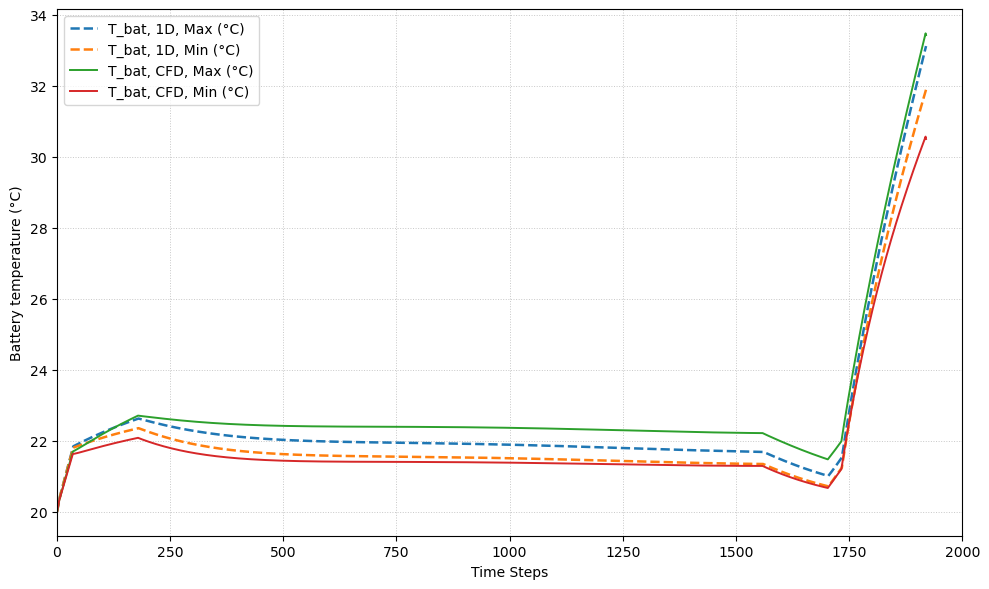


Selected-condition results:
  Tmax = 33.130 °C
  DeltaTmax = 1.228 °C
  P_pump,total = 0.0341 W
  E_pump = 65.44 J
  m_total = 3.024 kg

Saved figure: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0009R00_PARK25_LC_1D_VAL.png


In [8]:
# run the selected condition and plot 1D/CFD temperature histories

print('Running selected single condition...')
summary_row, histories = run_one_case(**single_case)

output_dir = OUTPUT_DIR
os.makedirs(output_dir, exist_ok=True)

# -----------------------------------------------------------------------------
# Read CFD temperature histories exported from Fluent
# -----------------------------------------------------------------------------
CFD_DATA_DIR = os.path.join(
    os.getcwd(),
    'data',
    'HP02E030113A2  result_T_peak_avg per bat cell_liquid cooling_CFD_val_Liu_20260723',
)

CFD_FILES = {
    'CFD_avg_max': 'bat_avg_max.out',
    'CFD_avg_min': 'bat_avg_min.out',
}


def read_fluent_temperature_history(file_path):
    """Read Fluent temperature-history data as time and temperature arrays.

    For the current Fluent report format, columns are Time Step, Temperature,
    and flow-time. The physical flow-time is used for the x-axis.
    Temperatures are converted from K to degC when their median value is above
    150, which keeps already exported Celsius data unchanged.
    """
    rows = []

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        for line in file:
            stripped = line.strip()
            if not stripped:
                continue

            # Remove brackets and separators commonly found in Fluent .out files.
            cleaned = re.sub(r'[(),]', ' ', stripped)
            tokens = cleaned.split()

            numeric_values = []
            all_numeric = True
            for token in tokens:
                try:
                    numeric_values.append(float(token))
                except ValueError:
                    all_numeric = False
                    break

            # Fluent report files used here contain:
            #   Time Step, Temperature, flow-time
            # Therefore, for three or more numeric columns, use the last
            # column as physical time and the penultimate column as temperature.
            # A plain two-column file is interpreted as time, temperature.
            if all_numeric and len(numeric_values) >= 3:
                rows.append([numeric_values[-1], numeric_values[-2]])
            elif all_numeric and len(numeric_values) == 2:
                rows.append([numeric_values[0], numeric_values[1]])

    if not rows:
        raise ValueError(
            f'No numeric time-temperature data were found in: {file_path}'
        )

    data = np.asarray(rows, dtype=float)
    time_cfd = data[:, 0]
    temperature_cfd = data[:, 1]

    valid = np.isfinite(time_cfd) & np.isfinite(temperature_cfd)
    time_cfd = time_cfd[valid]
    temperature_cfd = temperature_cfd[valid]

    if time_cfd.size == 0:
        raise ValueError(f'No finite CFD data were found in: {file_path}')

    # Sort by time and retain the last value when duplicate times are present.
    order = np.argsort(time_cfd, kind='stable')
    time_cfd = time_cfd[order]
    temperature_cfd = temperature_cfd[order]

    _, reverse_unique_indices = np.unique(time_cfd[::-1], return_index=True)
    keep = np.sort(time_cfd.size - 1 - reverse_unique_indices)
    time_cfd = time_cfd[keep]
    temperature_cfd = temperature_cfd[keep]

    # Fluent commonly exports absolute temperature in K.
    if np.nanmedian(temperature_cfd) > 150.0:
        temperature_cfd = temperature_cfd - 273.15

    return time_cfd, temperature_cfd


cfd_histories = {}
for line_name, file_basename in CFD_FILES.items():
    cfd_file_path = os.path.join(CFD_DATA_DIR, file_basename)

    if not os.path.isfile(cfd_file_path):
        raise FileNotFoundError(
            f'CFD result file not found: {cfd_file_path}\n'
            'Check that bat_avg_max.out and bat_avg_min.out are inside the specified data folder.'
        )

    cfd_histories[line_name] = read_fluent_temperature_history(cfd_file_path)

# -----------------------------------------------------------------------------
# Plot the 1D and CFD temperature histories
# -----------------------------------------------------------------------------
plt.rcdefaults()
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    histories['time_s'],
    histories['Tmax_C'],
    linewidth=1.8,
    linestyle='--',
    label='T_bat, 1D, Max (°C)',
)
ax.plot(
    histories['time_s'],
    histories['Tmin_C'],
    linewidth=1.8,
    linestyle='--',
    label='T_bat, 1D, Min (°C)',
)

CFD_LINE_STYLES = {
    'CFD_avg_max': '-',
    'CFD_avg_min': '-',
}

CFD_LEGEND_LABELS = {
    'CFD_avg_max': 'T_bat, CFD, Max (°C)',
    'CFD_avg_min': 'T_bat, CFD, Min (°C)',
}

for line_name in CFD_FILES:
    time_cfd, temperature_cfd = cfd_histories[line_name]
    ax.plot(
        time_cfd,
        temperature_cfd,
        linewidth=1.4,
        linestyle=CFD_LINE_STYLES[line_name],
        label=CFD_LEGEND_LABELS[line_name],
    )

ax.set_xlabel('Time Steps')
ax.set_ylabel('Battery temperature (°C)')
ax.set_xlim(0.0, 2000.0)
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
ax.legend()
fig.tight_layout()

figure_path = os.path.join(output_dir, RESULT_FIGURE_NAME)
fig.savefig(figure_path, dpi=600, bbox_inches='tight')
plt.show()

print()
print('Selected-condition results:')
print(f"  Tmax = {summary_row['Tmax_mission_C']:.3f} °C")
print(f"  DeltaTmax = {summary_row['DeltaT_mission_max_C']:.3f} °C")
print(f"  P_pump,total = {summary_row['P_pump']:.4f} W")
print(f"  E_pump = {summary_row['E_pump_cumulative']:.2f} J")
print(f"  m_total = {summary_row['mtotal']:.3f} kg")
print()
print(f'Saved figure: {figure_path}')
